# Telecom Complain Escalation - Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv(r"C:\Users\Nishant\Downloads\Telecom_Complain_Escalation_Dataset.csv")

In [3]:
df

,Ticket #,Customer Complaint,Date,Date_month_year,Time,Received Via,City,State,Zip code,Status,Filing on Behalf of Someone
0,250635,Comcast Cable Internet Speeds,22-04-15,22-Apr-15,3:53:50 PM,Customer Care Call,Abingdon,Maryland,21009,Closed,No
1,223441,Payment disappear - service got disconnected,04-08-15,04-Aug-15,10:22:56 AM,Internet,Acworth,Georgia,30102,Closed,No
2,242732,Speed and Service,18-04-15,18-Apr-15,9:55:47 AM,Internet,Acworth,Georgia,30101,Closed,Yes
3,277946,Comcast Imposed a New Usage Cap of 300GB that ...,05-07-15,05-Jul-15,11:59:35 AM,Internet,Acworth,Georgia,30101,Open,Yes
4,307175,Comcast not working and no service to boot,26-05-15,26-May-15,1:25:26 PM,Internet,Acworth,Georgia,30101,Solved,No
...,...,...,...,...,...,...,...,...,...,...,...
2219,213550,Service Availability,04-02-15,04-Feb-15,9:13:18 AM,Customer Care Call,Youngstown,Florida,32466,Closed,No
2220,318775,Comcast Monthly Billing for Returned Modem,06-02-15,06-Feb-15,1:24:39 PM,Customer Care Call,Ypsilanti,Michigan,48197,Solved,No
2221,331188,complaint about comcast,06-09-15,06-Sep-15,5:28:41 PM,Internet,Ypsilanti,Michigan,48197,Solved,No
2222,360489,Extremely unsatisfied Comcast customer,23-06-15,23-Jun-15,11:13:30 PM,Customer Care Call,Ypsilanti,Michigan,48197,Solved,No


In [4]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Ticket #                     2224 non-null   object
 1   Customer Complaint           2224 non-null   object
 2   Date                         2224 non-null   object
 3   Date_month_year              2224 non-null   object
 4   Time                         2224 non-null   object
 5   Received Via                 2224 non-null   object
 6   City                         2224 non-null   object
 7   State                        2224 non-null   object
 8   Zip code                     2224 non-null   int64 
 9   Status                       2224 non-null   object
 10  Filing on Behalf of Someone  2224 non-null   object
dtypes: int64(1), object(10)
memory usage: 191.3+ KB


,Ticket #,Customer Complaint,Date,Date_month_year,Time,Received Via,City,State,Zip code,Status,Filing on Behalf of Someone
count,2224,2224,2224,2224,2224,2224,2224,2224,2224.000000,2224,2224
unique,2224,1841,91,91,2190,2,928,43,NaN,4,2
top,250635,Comcast,24-06-15,24-Jun-15,12:41:14 PM,Customer Care Call,Atlanta,Georgia,NaN,Solved,No
freq,1,83,218,218,2,1119,63,288,NaN,973,2021
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47994.393435,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28885.279427,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1075.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30056.500000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37211.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77058.750000,NaN,NaN


In [5]:
df.isnull().sum()

Ticket #                       0
Customer Complaint             0
Date                           0
Date_month_year                0
Time                           0
Received Via                   0
City                           0
State                          0
Zip code                       0
Status                         0
Filing on Behalf of Someone    0
dtype: int64

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2219    False
2220    False
2221    False
2222    False
2223    False
Length: 2224, dtype: bool

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

C:\Users\Nishant\AppData\Local\Temp\ipykernel_22984\2624385925.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [8]:
df.head()

,Ticket #,Customer Complaint,Date,Date_month_year,Time,Received Via,City,State,Zip code,Status,Filing on Behalf of Someone,Year,Month,Day
0,250635,Comcast Cable Internet Speeds,2015-04-22,22-Apr-15,3:53:50 PM,Customer Care Call,Abingdon,Maryland,21009,Closed,No,2015,4,22
1,223441,Payment disappear - service got disconnected,2015-04-08,04-Aug-15,10:22:56 AM,Internet,Acworth,Georgia,30102,Closed,No,2015,4,8
2,242732,Speed and Service,2015-04-18,18-Apr-15,9:55:47 AM,Internet,Acworth,Georgia,30101,Closed,Yes,2015,4,18
3,277946,Comcast Imposed a New Usage Cap of 300GB that ...,2015-05-07,05-Jul-15,11:59:35 AM,Internet,Acworth,Georgia,30101,Open,Yes,2015,5,7
4,307175,Comcast not working and no service to boot,2015-05-26,26-May-15,1:25:26 PM,Internet,Acworth,Georgia,30101,Solved,No,2015,5,26


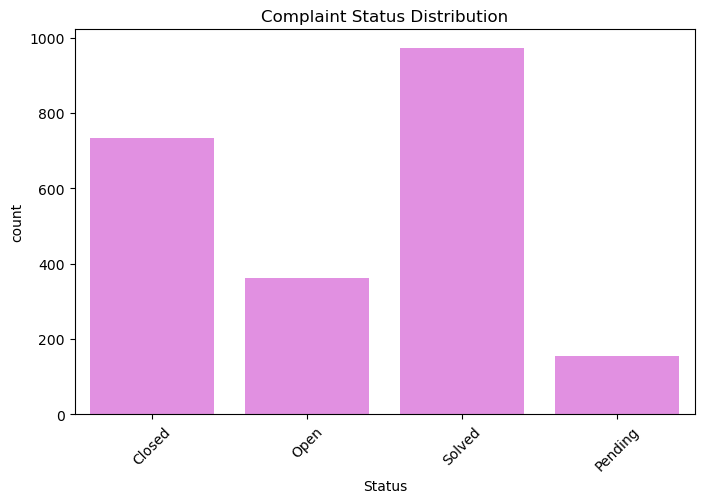

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Status', color="Violet", data=df)
plt.title("Complaint Status Distribution")
plt.xticks(rotation=45)
plt.show()

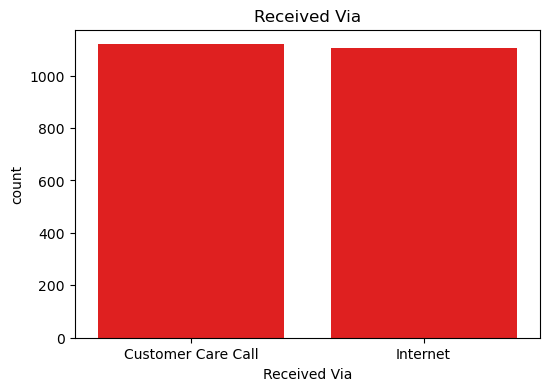

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Received Via',color="Red",data=df)
plt.title("Received Via")
plt.show()

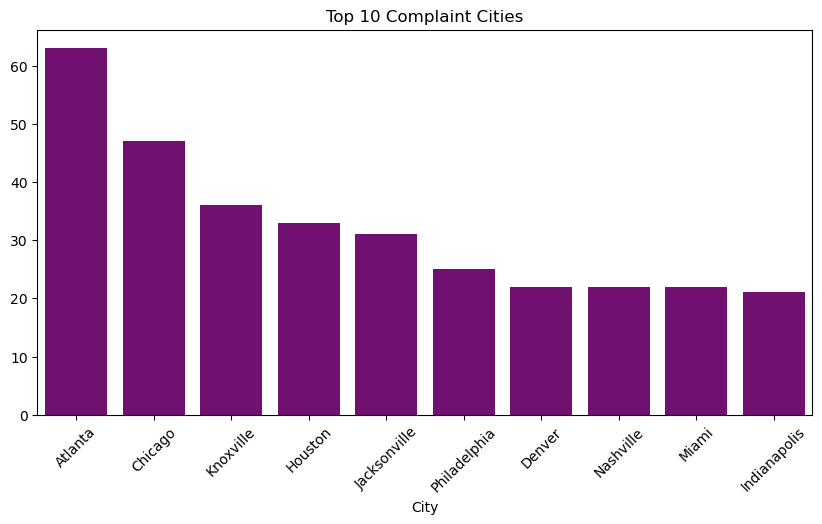

In [11]:
top_city = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_city.index,color="Purple",y=top_city.values)

plt.xticks(rotation=45)
plt.title("Top 10 Complaint Cities")
plt.show()

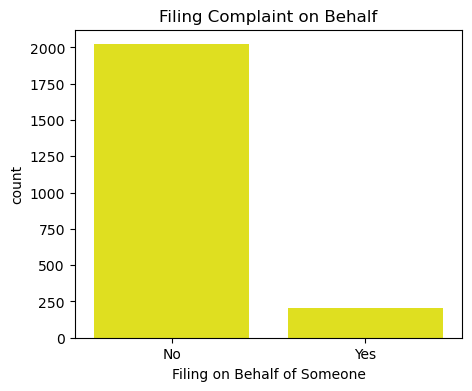

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='Filing on Behalf of Someone',color="Yellow" ,data=df)
plt.title("Filing Complaint on Behalf")
plt.show()

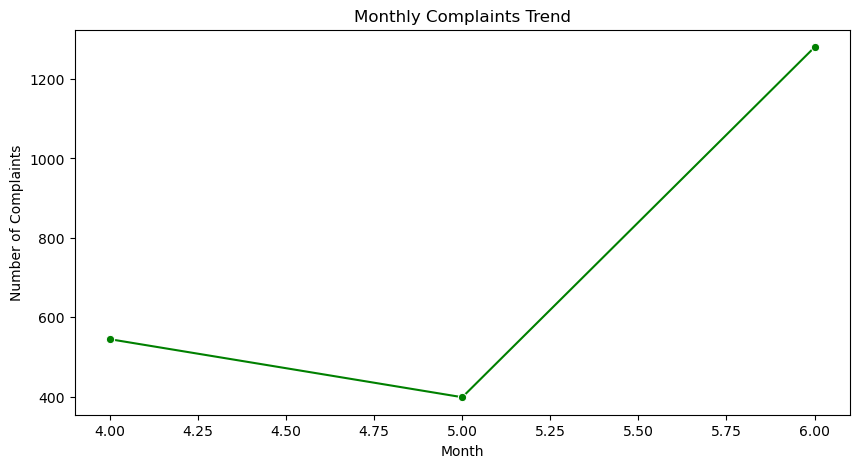

In [13]:
monthly = df['Month'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly.index, y=monthly.values,color="Green", marker='o')
plt.title("Monthly Complaints Trend")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.show()

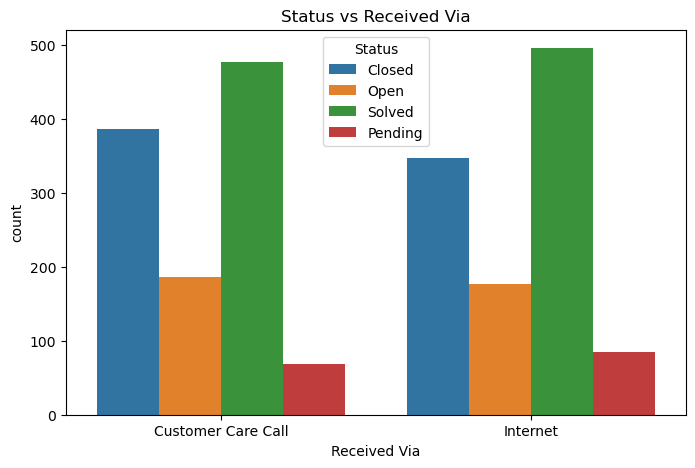

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='Received Via', hue='Status', data=df)
plt.title("Status vs Received Via")
plt.show()

In [15]:
df_model = df.copy()

df_model.drop([
    'Ticket #',
    'Customer Complaint',
    'Date',
    'Date_month_year',
    'Time'
], axis=1, inplace=True)

In [16]:
le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

In [17]:
X = df_model.drop('Status', axis=1)
y = df_model['Status']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [19]:
#Decision Tree Model
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    random_state=42)
dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred = dt.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6674157303370787


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       154
           1       0.22      0.11      0.14        65
           2       0.40      0.05      0.10        37
           3       0.60      0.86      0.71       189

    accuracy                           0.67       445
   macro avg       0.53      0.46      0.45       445
weighted avg       0.64      0.67      0.63       445



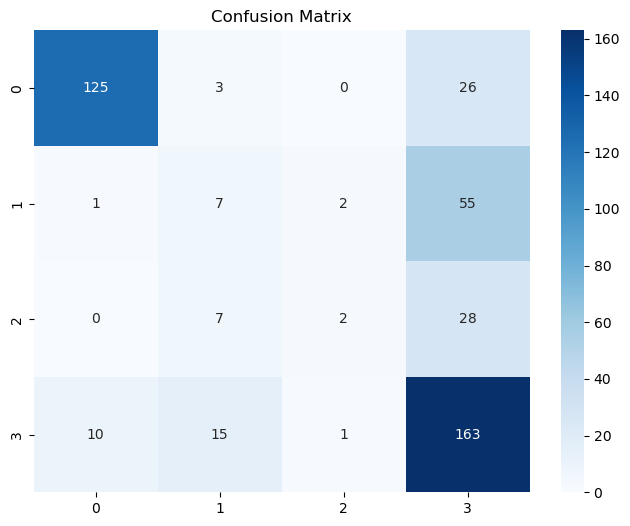

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_})
importance = importance.sort_values(
    by='Importance',
    ascending=False)
print(importance)

                       Feature  Importance
6                        Month    0.645758
7                          Day    0.215486
3                     Zip code    0.058012
2                        State    0.041798
1                         City    0.029921
4  Filing on Behalf of Someone    0.005968
0                 Received Via    0.003058
5                         Year    0.000000


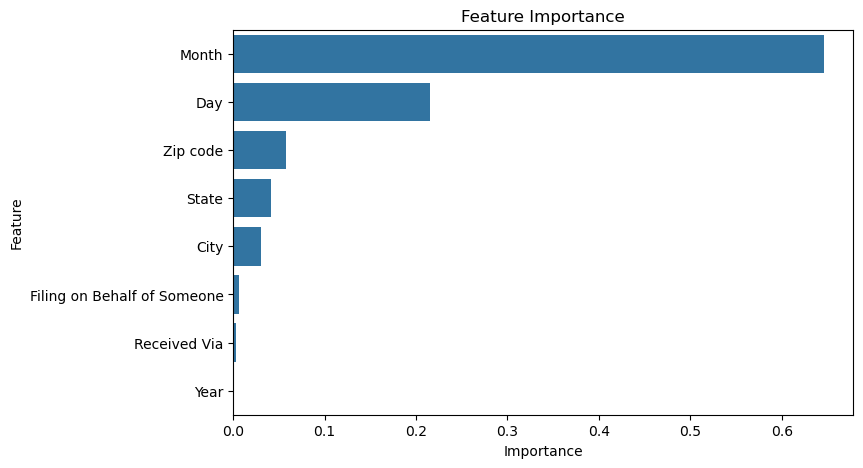

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=importance)
plt.title("Feature Importance")
plt.show()

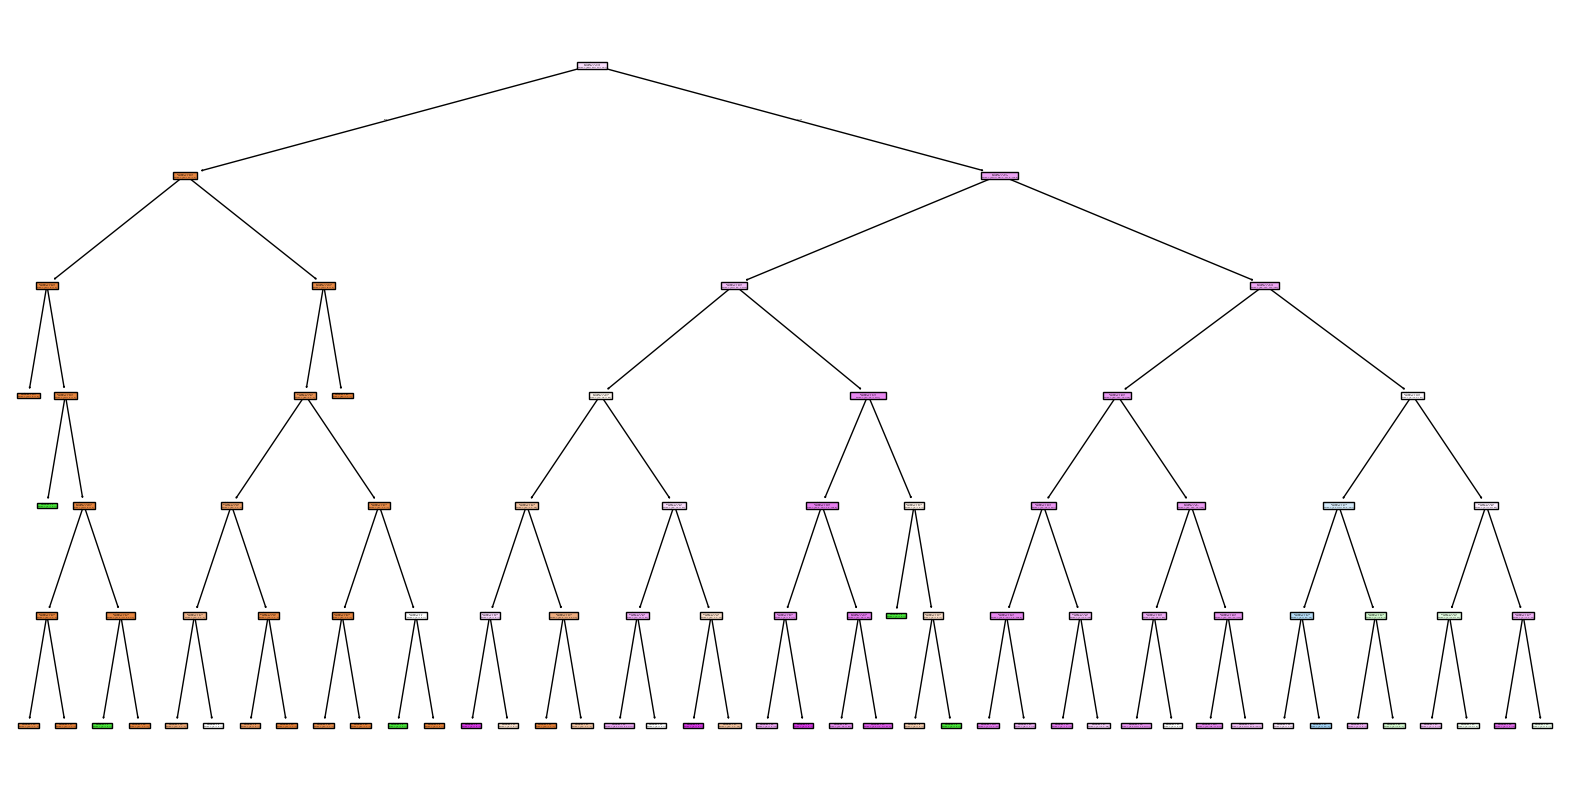

In [26]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=X.columns,filled=True)
plt.show()